In [1]:
pip install ucimlrepo


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE


In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
x = heart_disease.data.features 
y = heart_disease.data.targets 
#converting to dataframe by concating
df=pd.concat([x,y],axis=1)
print(df.head())
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())
print(df.isnull().sum())

  



   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  num  
0  0.0   6.0    0  
1  3.0   3.0    2  
2  2.0   7.0    1  
3  0.0   3.0    0  
4  0.0   3.0    0  
(303, 14)
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   

**Cleaning missing values**

In [4]:
df.dropna(inplace=True)
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [5]:
#understanding the target variables
print(y.value_counts())

num
0      164
1       55
2       36
3       35
4       13
Name: count, dtype: int64


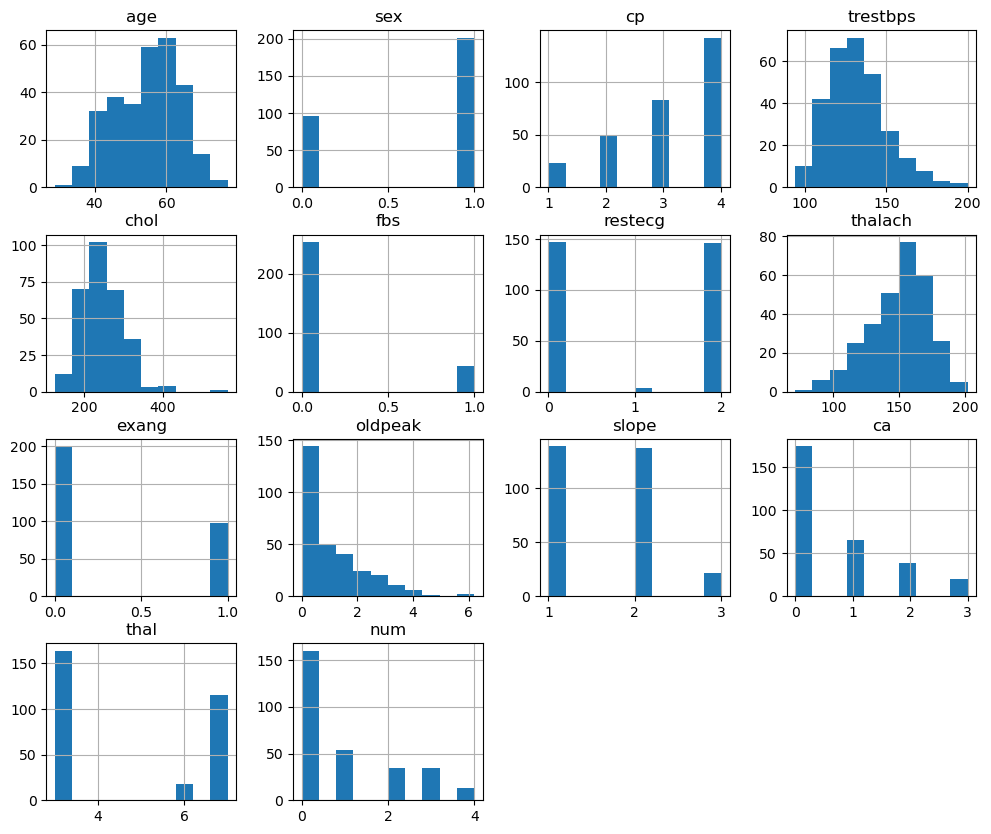

In [6]:
df.corr()
df.hist(figsize=(12,10))
plt.show()

**Correlation using seaborn**

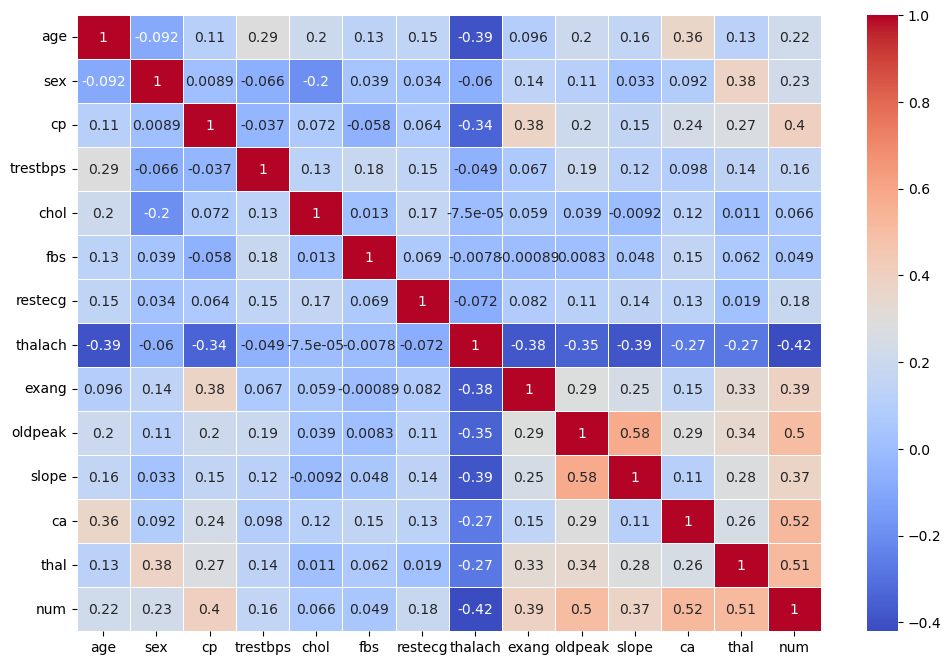

In [7]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',linewidths=0.5)

plt.show()


**dropping weak correalted features**

In [8]:
df.drop(columns=['fbs','chol'],inplace=True)
print(df.columns.tolist())

['age', 'sex', 'cp', 'trestbps', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


**feature and target**

In [9]:
x=df.drop('num',axis=1)
y=df['num']

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import seaborn as sns



In [11]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
print(x_scaled)

[[ 0.93618065  0.69109474 -2.24062879 ...  2.26414539 -0.72197605
   0.65587737]
 [ 1.3789285   0.69109474  0.87388018 ...  0.6437811   2.47842525
  -0.89422007]
 [ 1.3789285   0.69109474  0.87388018 ...  0.6437811   1.41162482
   1.17257652]
 ...
 [ 1.48961547  0.69109474  0.87388018 ...  0.6437811   1.41162482
   1.17257652]
 [ 0.27205887  0.69109474  0.87388018 ...  0.6437811   0.34482438
   1.17257652]
 [ 0.27205887 -1.44697961 -1.20245913 ...  0.6437811   0.34482438
  -0.89422007]]


**Split**

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,random_state=42)

In [13]:
#apply smote on trainig data only
smote=SMOTE(random_state=42)
x_train_sm,y_train_sm=smote.fit_resample(x_train,y_train)

**Logistic regression with softmax**

In [14]:
model=LogisticRegression(solver='lbfgs',
                         max_iter=1000,
                        class_weight='balanced')##becaues of too many 0s in the predicted value model is biased toward class 0
model.fit(x_train_sm,y_train_sm)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

**Testing**

In [15]:
y_predict=model.predict(x_test)
y_predict

array([0, 0, 0, 4, 0, 0, 0, 1, 4, 0, 1, 0, 0, 0, 0, 0, 1, 1, 2, 0, 2, 1,
       0, 0, 2, 0, 3, 1, 0, 0, 0, 0, 3, 0, 0, 0, 2, 0, 4, 2, 0, 2, 3, 1,
       0, 1, 0, 3, 0, 0, 0, 4, 0, 0, 2, 2, 0, 0, 4, 3])

**Probabilty output(softmax)**

In [16]:
y_prob=model.predict_proba(x_test)
print("softmax probabilities (first 5 rows)")
print(pd.DataFrame(y_prob,columns=[f'class{i}'for i in model.classes_]).head())

softmax probabilities (first 5 rows)
     class0    class1    class2    class3        class4
0  0.923870  0.072386  0.003180  0.000565  3.194193e-08
1  0.521077  0.327418  0.147150  0.002949  1.405121e-03
2  0.937845  0.057115  0.004947  0.000091  1.322428e-06
3  0.000050  0.001677  0.017793  0.006221  9.742585e-01
4  0.819260  0.175290  0.005184  0.000266  3.031316e-07


**Evalaution Code**

**Accuracy**

In [17]:
print(f"\nAccuracy:{accuracy_score(y_test,y_predict)*100:.2f}%")


Accuracy:56.67%


**Detailed report**

In [18]:
print("\nclassification report:")
print(classification_report(y_test,y_predict))


classification report:
              precision    recall  f1-score   support

           0       0.91      0.86      0.89        36
           1       0.25      0.22      0.24         9
           2       0.12      0.20      0.15         5
           3       0.00      0.00      0.00         7
           4       0.00      0.00      0.00         3

    accuracy                           0.57        60
   macro avg       0.26      0.26      0.25        60
weighted avg       0.59      0.57      0.58        60



**confusion matrix**

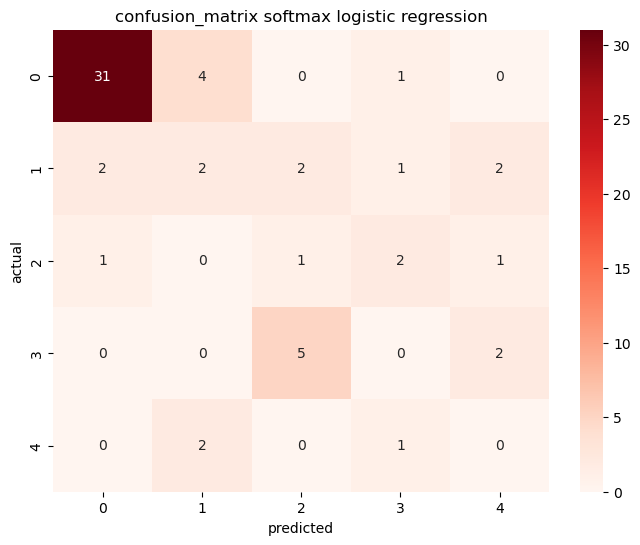

In [19]:
plt.figure(figsize=(8,6))
cm=confusion_matrix(y_test,y_predict)
sns.heatmap(cm,annot=True,fmt='d',cmap='Reds',
           xticklabels=model.classes_,
           yticklabels=model.classes_)
plt.title('confusion_matrix softmax logistic regression')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.show()

In [20]:
print(df['num'].value_counts())

num
0    160
1     54
2     35
3     35
4     13
Name: count, dtype: int64
